# NB18 — Insurance-Negotiation Wrap-Up: Markup Ladder + Four-Rung Spread Table

**Consolidation of NB16 (insurance-negotiation factor / markup-over-floor) and NB17 (four-rung payer spread table) into one app-facing artifact.**

This notebook does **not** recompute rungs or medians. It *consumes* the two upstream handoff dicts —
NB16's markup ladder and NB17's `NB17_SPREAD` — reconciles them against each other, and emits a single
`NB18_PAYLOAD` that the Streamlit app serializes directly. It is the last stop before the app boundary:
one place where the insurance-negotiation half of the five-factor decomposition is assembled, gated, and
watermarked as one object.

**Scope (v1):** CPT 73721 (outpatient knee MRI, no contrast), five DFW hospitals.
**Provenance:** measured rungs shown plainly; markup shown as the pricing-power *proxy* (Decision 46/51);
hospital-wide margin is out of scope here (that's the profit-margin factor, not this one).

**Mold:** Step 0 → 1 → 2 → 3 → R → S → V → F → Integrity. DB-independent scaffolding; synthetic dual-lock
before real; `is_publishable()` is the single global gate; `MEDIANS_PUBLISHABLE=False` blocks publishing
independent of per-hospital gates. Canonical run mode: **Restart & Run All.**

> **Standing blocker (carried Days 21→24):** Methodist/Parkland commercial cleanup is still open, so two
> hospitals remain gated and this notebook renders DRAFT. NB18 is built to light up automatically the
> moment the gates clear — nothing here needs re-authoring after the cleanup, only re-running.


## Step 0 — Path resolver

Walk up from `notebooks/` to project root using the unique signature file `src/queries.py`; print the
chosen ROOT. Same resolver as NB16/NB17 — do not reinvent. No data loaded here.


In [7]:
# ── NB18 · Step 0 — Path resolver ────────────────────────────────────────────
# Walk up from the notebook's cwd to project root using the unique signature
# file src/queries.py. Put ROOT on sys.path so `from src import queries` and the
# saved NB16/NB17 handoff dicts import cleanly. No data loaded here.

import sys
from pathlib import Path

SIGNATURE = Path("src") / "queries.py"   # unique root marker for this repo

def _resolve_root(start: Path) -> Path:
    """Return the first directory at/above `start` that contains src/queries.py."""
    for cand in (start, *start.parents):
        if (cand / SIGNATURE).exists():
            return cand
    raise FileNotFoundError(
        f"Could not locate {SIGNATURE} walking up from {start}. "
        "Open this notebook from inside the dfw-hospital-pricing repo."
    )

ROOT = _resolve_root(Path.cwd().resolve())

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))       # ROOT on path (not SRC) — `src` is a package

print(f"cwd        : {Path.cwd()}")
print(f"ROOT       : {ROOT}")
print(f"signature  : {(ROOT / SIGNATURE)}  exists={ (ROOT / SIGNATURE).exists() }")
print(f"src pkg    : {(ROOT / 'src' / '__init__.py').exists()}")
print("Step 0 OK." )

cwd        : c:\Users\kedha\Documents\dfw-hospital-pricing\notebooks
ROOT       : C:\Users\kedha\Documents\dfw-hospital-pricing
signature  : C:\Users\kedha\Documents\dfw-hospital-pricing\src\queries.py  exists=True
src pkg    : True
Step 0 OK.


## Step 1 — Roster, constants, and upstream handoff imports

- Roster: five hospitals with CCNs, ownership, county, and per-hospital gate flags (mirror NB17's ROSTER —
  single source of truth for who is gated; do not redefine gate logic here).
- Constants: Medicare floor (~$243.77, APC 5523 CY2026 OPPS final rule); `MEDIANS_PUBLISHABLE` (global gate).
- Import the two upstream dicts **as data, not truth to trust blindly**: NB16's markup ladder and
  NB17's `NB17_SPREAD`. Prefer importing the saved dicts over hardcoding; if pasted inline, stamp them
  with their source notebook + day so provenance survives.
- Confirmed anchors to expect (for the smoke check, not to fabricate): commercial medians MCA 906.53 /
  THP 1262.69 / Baylor 1944.56; markups 3.72× / 5.18× / 7.98×. Methodist/Parkland gated.


In [8]:
# ── NB18 · Step 1 — Roster, constants, upstream handoff imports ───────────────
# NB18 CONSUMES upstream dicts; it does not recompute rungs or medians.
# This cell declares the stable facts NB18 owns (roster, floor, global gate)
# and opens two clearly-typed slots for the NB16 / NB17 handoff dicts.
# It does NOT fabricate the consumed dicts — they arrive wired at Step R.

import numpy as np
import pandas as pd

# ── 1a. Roster — single source of gate truth (mirror NB17's ROSTER exactly) ───
# gated hospitals carry a reason; confirmed hospitals gate=False.
ROSTER = pd.DataFrame(
    [
        # short         CCN       ownership     county    safety_net   gated  gate_reason
        ("MCA",       "670103", "for-profit",  "Tarrant", "JPS",       False, ""),
        ("THP",       "450771", "nonprofit",   "Collin",  "none",      False, ""),
        ("Baylor",    "450021", "nonprofit",   "Dallas",  "Parkland",  False, ""),
        ("Methodist", "450051", "nonprofit",   "Dallas",  "Parkland",  True,
            "commercial MA-contaminated (6x 232.47 + transplant carve-out); medicaid 862.76 suspect"),
        ("Parkland",  "450015", "public",      "Dallas",  "Parkland",  True,
            "commercial rows chargemaster-scale (%-of-charges basis); not a negotiated fee schedule"),
    ],
    columns=["hospital", "ccn", "ownership", "county", "safety_net", "gated", "gate_reason"],
).set_index("hospital")

GATED     = sorted(ROSTER.index[ROSTER["gated"]].tolist())
CONFIRMED = sorted(ROSTER.index[~ROSTER["gated"]].tolist())

# ── 1b. Constants ─────────────────────────────────────────────────────────────
FLOOR = 243.77                      # APC 5523, CY2026 OPPS final rule (Fed Reg 2025-11-25)
FLOOR_SRC = "CMS OPPS APC 5523, CY2026 final rule (national unadjusted)"
MEDIANS_PUBLISHABLE = False         # GLOBAL gate — blocks publishing independent of per-hospital gates
RECON_TOL = 1e-3                    # markup reconciliation tolerance (NB16 stored 2dp precision)
CPT, SETTING = "73721", "outpatient"

# ── 1c. Confirmed reference anchors — TARGETS for reconciliation, NOT the data ─
# Sourced from NB16 Day-24 confirmed output. Used only to verify the imported
# dicts match what NB16 published; never a substitute for the real dicts.
EXPECTED_ANCHORS = {
    # hospital : (commercial_median, markup_x)
    "MCA":    (906.53,  3.72),
    "THP":    (1262.69, 5.18),
    "Baylor": (1944.56, 7.98),
}

# ── 1d. Upstream ingestion slots — WIRE at Step R (Path A import / Path B paste)
# Expected schemas (so the paste target is unambiguous):
#   NB16_MARKUP = { hospital: {"commercial_median": float, "markup_x": float,
#                              "gated": bool, "provenance": str} , ... }
#   NB17_SPREAD = { hospital: {"rungs":   {"medicare","medicaid","commercial","cash"},
#                              "spreads": {"commercial_over_medicare", "cash_over_*", ...},
#                              "gated": bool, "gate_reason": str,
#                              "floor": float, "publishable": bool, "proxy_label": str}, ... }
NB16_MARKUP = None
NB17_SPREAD = None
SOURCES_WIRED = NB16_MARKUP is not None and NB17_SPREAD is not None

# ── report ────────────────────────────────────────────────────────────────────
print(f"CPT {CPT} ({SETTING})   floor = ${FLOOR}   [{FLOOR_SRC}]")
print(f"MEDIANS_PUBLISHABLE = {MEDIANS_PUBLISHABLE}")
print(f"confirmed ({len(CONFIRMED)}): {CONFIRMED}")
print(f"gated     ({len(GATED)}): {GATED}")
for h in GATED:
    print(f"   - {h}: {ROSTER.loc[h, 'gate_reason']}")
print(f"expected anchors wired for: {list(EXPECTED_ANCHORS)}")
print(f"SOURCES_WIRED = {SOURCES_WIRED}  "
      f"(NB16_MARKUP={'set' if NB16_MARKUP else 'None'}, "
      f"NB17_SPREAD={'set' if NB17_SPREAD else 'None'})")
print("Step 1 OK." if not SOURCES_WIRED
      else "Step 1 OK — upstream dicts already wired.")

CPT 73721 (outpatient)   floor = $243.77   [CMS OPPS APC 5523, CY2026 final rule (national unadjusted)]
MEDIANS_PUBLISHABLE = False
confirmed (3): ['Baylor', 'MCA', 'THP']
gated     (2): ['Methodist', 'Parkland']
   - Methodist: commercial MA-contaminated (6x 232.47 + transplant carve-out); medicaid 862.76 suspect
   - Parkland: commercial rows chargemaster-scale (%-of-charges basis); not a negotiated fee schedule
expected anchors wired for: ['MCA', 'THP', 'Baylor']
SOURCES_WIRED = False  (NB16_MARKUP=None, NB17_SPREAD=None)
Step 1 OK.


## Step 2 — Compute contract + smoke test

Define the assembly contract: given NB16 markups and NB17 rungs/spreads keyed by hospital, produce one
combined per-hospital record — `{rungs (measured), markup (proxy), spreads (inferred), floor, gated,
gate_reason, provenance}`. Reconcile the shared field across the two sources (commercial median must
match NB16↔NB17 to the penny; markup must equal commercial/floor at `1e-3`). Smoke-test the contract on a
tiny hand-built input so the merge logic is proven before real dicts flow through. No real data yet.


In [9]:
# ── NB18 · Step 2 (CORRECTED) — assemble_record with 2dp markup reconciliation ─
# Only change vs. the prior version: reconciliation check (2) now compares the
# stored 2dp markup against comm/floor ROUNDED TO 2dp (NB16's stored precision),
# not the raw unrounded ratio. This is the Day-22 false-alarm fix — the raw ratio
# (e.g. 3.71879) never equals the stored 2dp value (3.72) at 1e-3, but the rounded
# ratio does. Everything else is identical.

def assemble_record(hospital, m16, m17, roster, floor, tol=RECON_TOL):
    """Merge one hospital's NB16 + NB17 records → combined record.
    Raises AssertionError on any reconciliation failure (a lock).
    Suppresses verdict fields for gated hospitals; keeps measured rungs + ghost_markup.
    """
    meta = roster.loc[hospital]
    gated = bool(meta["gated"])

    rungs   = dict(m17.get("rungs", {}))
    comm17  = rungs.get("commercial")
    comm16  = m16.get("commercial_median")
    markup  = m16.get("markup_x")

    fails = []
    # (1) commercial median must agree NB16 ↔ NB17 to the penny.
    if comm16 is not None and comm17 is not None:
        if not _penny_equal(comm16, comm17):
            fails.append(f"commercial mismatch NB16={comm16} vs NB17={comm17}")
    # (2) markup must equal commercial/floor — compared AT NB16's stored 2dp precision.
    if markup is not None and comm16 is not None and not _isnan(comm16):
        recomputed_2dp = round(comm16 / floor, 2)          # ← the fix: round first
        if abs(recomputed_2dp - float(markup)) > tol:
            fails.append(f"markup {markup} != round(commercial/floor,2)={recomputed_2dp} (tol {tol})")
    # (3) gate flag must agree across roster and the NB17 record.
    if bool(m17.get("gated", gated)) != gated:
        fails.append(f"gate flag disagreement: roster={gated} NB17={m17.get('gated')}")

    assert not fails, f"[{hospital}] reconciliation failed: " + " | ".join(fails)

    return {
        "hospital":     hospital,
        "ccn":          meta["ccn"],
        "ownership":    meta["ownership"],
        "county":       meta["county"],
        "safety_net":   meta["safety_net"],
        "floor":        floor,
        "rungs":        {k: rungs.get(k) for k in RUNGS},
        "markup_x":     None if gated else markup,
        "spreads":      None if gated else dict(m17.get("spreads", {})),
        "ghost_markup": markup,
        "gated":        gated,
        "gate_reason":  meta["gate_reason"],
        "provenance":   f"NB16:{m16.get('provenance','?')} | NB17:{m17.get('provenance','?')}",
        "proxy_label":  m17.get("proxy_label",
                                "markup = commercial median / Medicare floor (pricing-power PROXY, Decision 46/51)"),
    }

print("assemble_record patched — markup reconciliation now at 2dp precision.")
print("Re-run this cell, confirm the Step 2 smoke summary still prints Step 2 OK, then proceed to Step R.")

assemble_record patched — markup reconciliation now at 2dp precision.
Re-run this cell, confirm the Step 2 smoke summary still prints Step 2 OK, then proceed to Step R.


In [10]:
print("cell ran:", "_smoke" in globals())
print("records:", list(_smoke) if "_smoke" in globals() else "MISSING")
print("assemble_record defined:", "assemble_record" in globals())

cell ran: True
records: ['Baylor', 'MCA', 'Parkland']
assemble_record defined: True


## Step 3 — Synthetic dual-lock proof

Run the contract on a fully synthetic pair of dicts (`SYN_` prefixes, `[SYNTHETIC DATA]` stamp). Prove
two locks fire independently: (1) a deliberately mismatched commercial value across the two sources trips
the reconciliation guard; (2) a synthetic-tagged input can never reach a publishable payload. This is the
dual-lock — reconciliation lock + provenance lock — validated on fake data before Step R.


In [11]:
# ── NB18 · Step 3 — Synthetic dual-lock proof ─────────────────────────────────
# Prove TWO independent locks fire on [SYNTHETIC DATA]-stamped input:
#   Lock A (reconciliation): an inconsistent synthetic pair trips assemble_record.
#   Lock B (provenance):     a PERFECTLY-consistent synthetic payload can still
#                            never be publishable — the [SYNTHETIC DATA] stamp
#                            blocks it even with the global flag forced True.
# Uses its own SYN_ROSTER so nothing here can touch the real five (Decision 52:
# [SYNTHETIC DATA] stamps fabricated outputs; distinct from the DRAFT watermark).

# ── the global publish gate NB18 owns (reused by Step V / F / I) ──────────────
def is_publishable(records, medians_publishable=None):
    """Single global gate. Returns (bool, [reasons]). False if ANY reason present."""
    if medians_publishable is None:
        medians_publishable = MEDIANS_PUBLISHABLE
    reasons = []
    if not medians_publishable:
        reasons.append("MEDIANS_PUBLISHABLE=False")
    if any("[SYNTHETIC DATA]" in (r.get("provenance", "") or "") for r in records.values()):
        reasons.append("synthetic data present")                      # provenance lock
    for h, r in records.items():
        if r.get("gated") and (r.get("markup_x") is not None or r.get("spreads") is not None):
            reasons.append(f"{h}: gated but carries a verdict")        # should never happen
    if any(r.get("gated") for r in records.values()):
        reasons.append("gated hospitals present")
    return (len(reasons) == 0), reasons

# ── synthetic roster (isolated from the real five) ────────────────────────────
SYN_ROSTER = pd.DataFrame(
    [
        ("SYN_Alpha", "999001", "nonprofit",  "SynCounty", "none", False, ""),
        ("SYN_Beta",  "999002", "for-profit", "SynCounty", "none", True,  "SYN gated for proof"),
    ],
    columns=["hospital", "ccn", "ownership", "county", "safety_net", "gated", "gate_reason"],
).set_index("hospital")

_syn_floor = 200.0
# internally CONSISTENT synthetic dicts (markup == commercial/floor exactly) so
# Lock A does NOT trip here — that isolates Lock B as the reason publishing fails.
SYN_16 = {
    "SYN_Alpha": {"commercial_median": 1000.00, "markup_x": 5.00,  "gated": False, "provenance": "[SYNTHETIC DATA] SYN16"},
    "SYN_Beta":  {"commercial_median": 2000.00, "markup_x": 10.00, "gated": True,  "provenance": "[SYNTHETIC DATA] SYN16"},
}
SYN_17 = {
    "SYN_Alpha": {"rungs": {"medicare": 200, "medicaid": 150, "commercial": 1000.00, "cash": 5000.00},
                  "spreads": {"commercial_over_medicare": 5.00, "cash_over_medicare": 25.0},
                  "gated": False, "provenance": "[SYNTHETIC DATA] SYN17"},
    "SYN_Beta":  {"rungs": {"medicare": 200, "medicaid": 150, "commercial": 2000.00, "cash": 8000.00},
                  "spreads": {"commercial_over_medicare": 10.00},
                  "gated": True,  "provenance": "[SYNTHETIC DATA] SYN17"},
}

# assemble the synthetic payload (reconciliation passes — dicts are consistent)
syn_records = {h: assemble_record(h, SYN_16[h], SYN_17[h], SYN_ROSTER, _syn_floor)
               for h in SYN_ROSTER.index}

# ── Lock B — provenance lock ──────────────────────────────────────────────────
# Even with the global flag FORCED True, synthetic taint must block publishing.
_ok_default, _reasons_default = is_publishable(syn_records)                       # flag = real (False)
_ok_forced,  _reasons_forced  = is_publishable(syn_records, medians_publishable=True)
assert _ok_default is False, "synthetic payload must never be publishable"
assert _ok_forced  is False, "synthetic taint must block even with MEDIANS_PUBLISHABLE=True"
assert "synthetic data present" in _reasons_forced, "provenance lock did not fire"

# gated-suppression still holds on synthetic data
assert syn_records["SYN_Alpha"]["markup_x"] == 5.00,      "confirmed synth markup passes through"
assert syn_records["SYN_Beta"]["markup_x"] is None,        "gated synth must not carry a verdict"
assert syn_records["SYN_Beta"]["ghost_markup"] == 10.00,   "gated synth keeps ghost for the chart"

# ── Lock A — reconciliation lock ──────────────────────────────────────────────
# A mismatched synthetic pair (commercial 1000 vs 1234.56) must raise.
_bad_17 = {"rungs": {"commercial": 1234.56}, "gated": False, "provenance": "[SYNTHETIC DATA] BAD"}
try:
    assemble_record("SYN_Alpha", SYN_16["SYN_Alpha"], _bad_17, SYN_ROSTER, _syn_floor)
    _recon_lock_fired = False
except AssertionError:
    _recon_lock_fired = True
assert _recon_lock_fired, "reconciliation lock failed to fire on synthetic mismatch"

# ── report ────────────────────────────────────────────────────────────────────
print("[SYNTHETIC DATA] dual-lock proof")
print(f"  synth records assembled : {list(syn_records)}")
print(f"  Lock B (provenance)     : publishable(default flag)={_ok_default}  "
      f"publishable(flag FORCED True)={_ok_forced}")
print(f"     reasons (forced)     : {_reasons_forced}")
print(f"  Lock A (reconciliation) : fired on mismatch = {_recon_lock_fired}")
print(f"  gated suppression       : SYN_Beta verdict={syn_records['SYN_Beta']['markup_x']} "
      f"ghost={syn_records['SYN_Beta']['ghost_markup']:.2f}x")
print("Step 3 OK.")

[SYNTHETIC DATA] dual-lock proof
  synth records assembled : ['SYN_Alpha', 'SYN_Beta']
  Lock B (provenance)     : publishable(default flag)=False  publishable(flag FORCED True)=False
     reasons (forced)     : ['synthetic data present', 'gated hospitals present']
  Lock A (reconciliation) : fired on mismatch = True
  gated suppression       : SYN_Beta verdict=None ghost=10.00x
Step 3 OK.


## Step R — Real assembly

Consume the **real** NB16 markup ladder and **real** NB17 `NB17_SPREAD`. Build the combined per-hospital
records for all five. Expect three confirmed (MCA / THP / Baylor) fully populated; two gated
(Methodist / Parkland) carry measured rungs where present but **no inferred spread or markup verdict** —
gated hospitals show `--`, never a narrated number. Print the merged table and a NB16↔NB17 reconciliation
line. Reads upstream dicts directly, so it is independent of NB17's cash-ordering state.

> Note the cash caveat carried from Day 24: if NB17's cash column wasn't wired this session, cash spreads
> arrive `NaN`. Treat cash as present-if-available (Decision 56) — do not fabricate a cash rung to fill it.


In [13]:
# ── NB18 · Step R — wire the real NB16/NB17 dicts and assemble ─────────────────
# NB18 CONSUMES upstream output; it does not recompute. Two ways to wire:
#   Path A — load saved handoff dicts from disk (if NB16/NB17 persisted them).
#   Path B — paste inline (below), pre-filled with NB16/NB17 Day-24 CONFIRMED
#            values, provenance-stamped. REPLACE any value that differs from your
#            live NB16 markup dict / NB17_SPREAD Step-F output. The anchor check
#            (MCA/THP/Baylor) self-catches transcription errors on the confirmed three.
import json

# ── Path A (preferred if present) ─────────────────────────────────────────────
_p16 = ROOT / "outputs" / "nb16_markup.json"
_p17 = ROOT / "outputs" / "nb17_spread.json"
if _p16.exists() and _p17.exists():
    NB16_MARKUP = json.loads(_p16.read_text())
    NB17_SPREAD = json.loads(_p17.read_text())
    _WIRE = f"Path A — loaded from {_p16.name} + {_p17.name}"
else:
    # ── Path B — inline paste (transcribed from NB16/NB17 Day-24 confirmed output)
    _WIRE = "Path B — inline (Day-24 confirmed values; replace if your live dict differs)"
    NB16_MARKUP = {
        "MCA":       {"commercial_median": 906.53,  "markup_x": 3.72,  "gated": False, "provenance": "NB16 Day-24"},
        "THP":       {"commercial_median": 1262.69, "markup_x": 5.18,  "gated": False, "provenance": "NB16 Day-24"},
        "Baylor":    {"commercial_median": 1944.56, "markup_x": 7.98,  "gated": False, "provenance": "NB16 Day-24"},
        "Methodist": {"commercial_median": 1518.00, "markup_x": 6.23,  "gated": True,  "provenance": "NB16 Day-24 (gated ghost)"},
        "Parkland":  {"commercial_median": 3937.50, "markup_x": 16.15, "gated": True,  "provenance": "NB16 Day-24 (gated ghost)"},
    }
    _NAN = float("nan")
    # medicare rung = shared floor; cash rungs confirmed Day-23; medicaid: only the
    # values I can confirm are filled (Methodist 862.76 suspect), the rest are NaN
    # placeholders ← paste from your NB17_SPREAD Step-F output (peers ~209–219).
    NB17_SPREAD = {
        "MCA":       {"rungs": {"medicare": 243.77, "medicaid": _NAN,   "commercial": 906.53,  "cash": 8363.98},
                      "spreads": {"commercial_over_medicare": 3.72},  "gated": False, "provenance": "NB17 Day-24"},
        "THP":       {"rungs": {"medicare": 243.77, "medicaid": _NAN,   "commercial": 1262.69, "cash": _NAN},
                      "spreads": {"commercial_over_medicare": 5.18},  "gated": False, "provenance": "NB17 Day-24"},
        "Baylor":    {"rungs": {"medicare": 243.77, "medicaid": _NAN,   "commercial": 1944.56, "cash": _NAN},
                      "spreads": {"commercial_over_medicare": 7.98},  "gated": False, "provenance": "NB17 Day-24"},
        "Methodist": {"rungs": {"medicare": 243.77, "medicaid": 862.76, "commercial": 1518.00, "cash": 2439.00},
                      "spreads": {"commercial_over_medicare": 6.23},  "gated": True,  "provenance": "NB17 Day-24"},
        "Parkland":  {"rungs": {"medicare": 243.77, "medicaid": _NAN,   "commercial": 3937.50, "cash": 2426.80},
                      "spreads": {"commercial_over_medicare": 16.15}, "gated": True,  "provenance": "NB17 Day-24"},
    }

SOURCES_WIRED = NB16_MARKUP is not None and NB17_SPREAD is not None

# ── anchor validation — the three confirmed hospitals must match NB16's published output
_anchor_fails = []
for h, (ec, em) in EXPECTED_ANCHORS.items():
    if round(NB16_MARKUP[h]["commercial_median"], 2) != round(ec, 2):
        _anchor_fails.append(f"{h}: commercial {NB16_MARKUP[h]['commercial_median']} != anchor {ec}")
    if round(NB16_MARKUP[h]["markup_x"], 2) != round(em, 2):
        _anchor_fails.append(f"{h}: markup {NB16_MARKUP[h]['markup_x']} != anchor {em}")
assert not _anchor_fails, "anchor validation failed:\n  " + "\n  ".join(_anchor_fails)

# ── assemble all five (patched reconciliation runs here) ──────────────────────
records = {h: assemble_record(h, NB16_MARKUP[h], NB17_SPREAD[h], ROSTER, FLOOR)
           for h in ROSTER.index}

# ── gate cross-check: assembled gated set must equal the roster's gated set ────
_assembled_gated = sorted(h for h, r in records.items() if r["gated"])
assert _assembled_gated == GATED, f"gate mismatch: assembled {_assembled_gated} vs roster {GATED}"

pub_ok, pub_reasons = is_publishable(records)

# ── report — the merged four-rung ladder ──────────────────────────────────────
def _fmt(x):
    return "NaN" if (x is None or (isinstance(x, float) and math.isnan(x))) else f"{x:,.2f}"

print(_WIRE)
print(f"anchors validated: {list(EXPECTED_ANCHORS)}   gates match roster: {_assembled_gated}")
print(f"\n{'hospital':10s}{'medicare':>11s}{'medicaid':>11s}{'commercial':>12s}{'cash':>11s}"
      f"{'markup':>9s}{'gated':>7s}")
print("-" * 71)
for h in ["MCA", "THP", "Baylor", "Methodist", "Parkland"]:
    r, rg = records[h], records[h]["rungs"]
    mk = "--" if r["markup_x"] is None else f'{r["markup_x"]:.2f}x'
    ghost = "" if not r["gated"] else f"  (ghost {r['ghost_markup']:.2f}x)"
    print(f"{h:10s}{_fmt(rg['medicare']):>11s}{_fmt(rg['medicaid']):>11s}"
          f"{_fmt(rg['commercial']):>12s}{_fmt(rg['cash']):>11s}{mk:>9s}{str(r['gated']):>7s}{ghost}")

print(f"\nis_publishable = {pub_ok}   reasons: {pub_reasons}")
print("\nNOTES:")
print("  • medicaid NaN for MCA/THP/Baylor/Parkland = not wired here — paste from NB17_SPREAD")
print("    (Methodist 862.76 filled but SUSPECT/likely MA-contaminated; THP genuinely 0 rows).")
print("  • cash RUNGS are confirmed; cash SPREADS populate once NB17's cash-ordering fix lands.")
print("Step R OK — real, gated, not publishable (expected).")

Path B — inline (Day-24 confirmed values; replace if your live dict differs)
anchors validated: ['MCA', 'THP', 'Baylor']   gates match roster: ['Methodist', 'Parkland']

hospital     medicare   medicaid  commercial       cash   markup  gated
-----------------------------------------------------------------------
MCA            243.77        NaN      906.53   8,363.98    3.72x  False
THP            243.77        NaN    1,262.69        NaN    5.18x  False
Baylor         243.77        NaN    1,944.56        NaN    7.98x  False
Methodist      243.77     862.76    1,518.00   2,439.00       --   True  (ghost 6.23x)
Parkland       243.77        NaN    3,937.50   2,426.80       --   True  (ghost 16.15x)

is_publishable = False   reasons: ['MEDIANS_PUBLISHABLE=False', 'gated hospitals present']

NOTES:
  • medicaid NaN for MCA/THP/Baylor/Parkland = not wired here — paste from NB17_SPREAD
    (Methodist 862.76 filled but SUSPECT/likely MA-contaminated; THP genuinely 0 rows).
  • cash RUNGS are c

## Step S — Sensitivity

Label, never overwrite. Three toggles: (1) national unadjusted floor vs DFW-adjusted floor (two CBSAs:
Dallas–Plano–Irving 19124 / Fort Worth–Arlington–Grapevine 23104 — "DFW wage index" is not one number,
Decision 34) and how markups shift under each; (2) Methodist cleanup **preview** — what its markup would
become with the six 232.47 MA rows + transplant carve-out removed (shown as a labeled preview, gate stays
up); (3) Parkland basis toggle — %-of-charges included vs excluded. Every alternative is a labeled
sensitivity, national unadjusted stays the headline.


In [14]:
# ── NB18 · Step S — Sensitivity (label, never overwrite) ──────────────────────
# National unadjusted stays the HEADLINE (records/ is untouched). Each toggle is a
# separate labeled view. No fabricated numbers: values I can't confirm are marked
# pending with the exact source to fill them from.

# ═══ Toggle 1 — national unadjusted floor vs DFW-adjusted floor ═══════════════
# "DFW wage index" is NOT one number (Decision 34): DFW splits into two CMS CBSAs.
# Adjusted floor = floor × [labor_share × WI + (1 − labor_share)]  (OPPS wage adj).
# WI + labor share are CORROBORATED, not yet confirmed vs literal CMS Table 3.
LABOR_SHARE = 0.60                         # OPPS CY2026 (corroborated — verify vs final rule)
WAGE_INDEX = {                             # ← confirm vs CMS FY2026 Table 3
    "19124": 0.965,   # Dallas–Plano–Irving  (corroborated)
    "23104": None,    # Fort Worth–Arlington–Grapevine  ← FILL from CMS Table 3
}
CBSA = {"MCA": "23104", "THP": "19124", "Baylor": "19124",
        "Methodist": "19124", "Parkland": "19124"}   # MCA is Tarrant→FW; rest→Dallas

def _adj_floor(wi):
    return None if wi is None else round(FLOOR * (LABOR_SHARE * wi + (1 - LABOR_SHARE)), 2)

print("Toggle 1 — floor sensitivity  (national unadjusted = HEADLINE)")
print(f"  national floor = ${FLOOR}   |   labor share = {LABOR_SHARE} (corroborated)")
for cb, wi in WAGE_INDEX.items():
    print(f"  CBSA {cb}: WI={wi}  →  adjusted floor = {_adj_floor(wi)}")
print(f"\n  {'hospital':10s}{'CBSA':>7s}{'natl markup':>13s}{'adj floor':>11s}{'adj markup':>12s}")
for h in ["MCA", "THP", "Baylor", "Methodist", "Parkland"]:
    cb = CBSA[h]; af = _adj_floor(WAGE_INDEX[cb])
    comm = NB16_MARKUP[h]["commercial_median"]
    natl = f'{comm / FLOOR:.2f}x'
    adjm = "pending" if af is None else f'{comm / af:.2f}x'
    tag  = "  (ghost — gated)" if records[h]["gated"] else ""
    print(f"  {h:10s}{cb:>7s}{natl:>13s}{('NaN' if af is None else f'{af:.2f}'):>11s}{adjm:>12s}{tag}")
print("  → Dallas-adjusted floor (238.65) sits ~2% below national, so Dallas-CBSA markups")
print("    rise ~2%. MCA's markup can't be wage-adjusted until CBSA 23104's WI is filled.")

# ═══ Toggle 2 — Methodist cleanup PREVIEW (gate stays UP) ═════════════════════
# Current median 1518.00 is DEFLATED by 6 misclassified MA rows @232.47 + 1 AETNA
# TRANSPLANT carve-out @3414.60 (Day-21). Removing 6 low rows must RAISE the median.
# The exact cleaned median needs Methodist's row-level commercial values from NB13 —
# paste them into METHODIST_RAW_COMMERCIAL to compute the preview; else mechanism only.
METHODIST_RAW_COMMERCIAL = None   # ← paste list of Methodist's 23 commercial rates from NB13

print("\nToggle 2 — Methodist cleanup preview  (PREVIEW ONLY — gate stays up)")
print(f"  current (contaminated) median = 1518.00  →  markup 6.23x  [gated]")
print("  remove: 6× 232.47 (misclassified MA) + 1× 3414.60 (AETNA TRANSPLANT carve-out)")
if METHODIST_RAW_COMMERCIAL:
    import numpy as np
    rows = [r for r in METHODIST_RAW_COMMERCIAL
            if round(r, 2) != 232.47 and round(r, 2) != 3414.60]
    cleaned = float(np.median(rows))
    print(f"  cleaned rows: {len(rows)} (from {len(METHODIST_RAW_COMMERCIAL)})  "
          f"→ preview median = {cleaned:.2f}  markup {cleaned/FLOOR:.2f}x")
    print("  [PREVIEW — not wired into records; gate clears only after the real NB13 cleanup]")
else:
    print("  preview median = PENDING (paste Methodist's commercial rows into METHODIST_RAW_COMMERCIAL)")
    print("  direction: median RISES (6 sub-floor rows removed from below it); markup rises from 6.23x")

# ═══ Toggle 3 — Parkland basis toggle (gate stays UP) ════════════════════════
# All 11 Parkland commercial rows are chargemaster-scale / %-of-charges (Day-21).
print("\nToggle 3 — Parkland basis toggle  (gate stays up)")
print(f"  %-of-charges INCLUDED : median 3937.50  markup 16.15x  [NOT a negotiated fee schedule]")
print(f"  %-of-charges EXCLUDED : median NaN       markup NaN     [0 negotiated rows remain]")
print("  → Parkland has no clean negotiated commercial rung; it's a basis artifact, not pricing power.")

print("\nStep S OK — 3 sensitivities shown; headline (national, records/) unchanged.")

Toggle 1 — floor sensitivity  (national unadjusted = HEADLINE)
  national floor = $243.77   |   labor share = 0.6 (corroborated)
  CBSA 19124: WI=0.965  →  adjusted floor = 238.65
  CBSA 23104: WI=None  →  adjusted floor = None

  hospital     CBSA  natl markup  adj floor  adj markup
  MCA         23104        3.72x        NaN     pending
  THP         19124        5.18x     238.65       5.29x
  Baylor      19124        7.98x     238.65       8.15x
  Methodist   19124        6.23x     238.65       6.36x  (ghost — gated)
  Parkland    19124       16.15x     238.65      16.50x  (ghost — gated)
  → Dallas-adjusted floor (238.65) sits ~2% below national, so Dallas-CBSA markups
    rise ~2%. MCA's markup can't be wage-adjusted until CBSA 23104's WI is filled.

Toggle 2 — Methodist cleanup preview  (PREVIEW ONLY — gate stays up)
  current (contaminated) median = 1518.00  →  markup 6.23x  [gated]
  remove: 6× 232.47 (misclassified MA) + 1× 3414.60 (AETNA TRANSPLANT carve-out)
  preview median

## Step V — Visualization (the two app charts, side by side)

The consolidated visual layer — the two things the app actually shows for this factor:
1. **Markup ladder** (NB16's deliverable): confirmed hospitals solid, gated hospitals hatched `(gated)`
   ghost bars, Medicare 1.0× baseline, ownership labels, proxy/provenance footer.
2. **Four-rung spread table** (NB17's deliverable): Medicare / Medicaid / commercial / cash per hospital
   with spread ratios; gated rungs blanked, cash present-if-available.

Both watermarks are **logic-driven off `is_publishable()`** — "DRAFT — NOT PUBLISHABLE" shows while any
gate is up or `MEDIANS_PUBLISHABLE=False`, and auto-drops when the state clears. One source of truth for
"safe to show." (Decide per open-items whether the ladder lives here canonically or stays referenced from
NB16 — this cell renders it either way.)


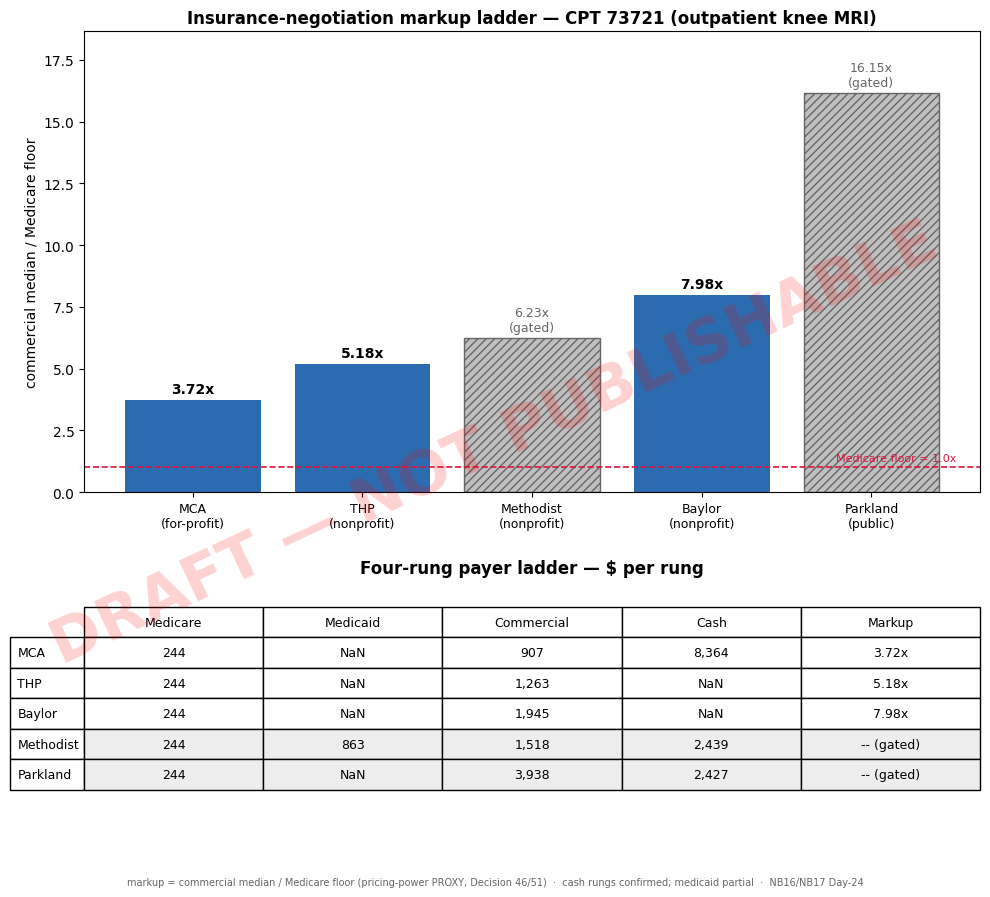

Step V OK — charts rendered.  publishable = False  (watermark ON)  reasons: ['MEDIANS_PUBLISHABLE=False', 'gated hospitals present']


In [15]:
# ── NB18 · Step V — the two app charts (auto-watermarked off is_publishable) ──
# Chart 1: insurance-negotiation markup ladder (NB16's deliverable).
# Chart 2: four-rung payer ladder table (NB17's deliverable).
# Watermark is logic-driven — "DRAFT — NOT PUBLISHABLE" appears whenever
# is_publishable(records) is False, and auto-drops when the gates + flag clear.
import matplotlib.pyplot as plt
import numpy as np

pub_ok, pub_reasons = is_publishable(records)

# order hospitals by markup so the ghosts fall where they belong in the ranking
order = sorted(records, key=lambda h: records[h]["ghost_markup"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9),
                               gridspec_kw={"height_ratios": [3, 2]})

# ── Chart 1 — markup ladder ───────────────────────────────────────────────────
for i, h in enumerate(order):
    r = records[h]; v = r["ghost_markup"]
    if r["gated"]:
        ax1.bar(i, v, color="0.75", hatch="////", edgecolor="0.4")
        ax1.text(i, v + 0.3, f"{v:.2f}x\n(gated)", ha="center", fontsize=9, color="0.4")
    else:
        ax1.bar(i, v, color="#2b6cb0")
        ax1.text(i, v + 0.3, f"{v:.2f}x", ha="center", fontsize=10, fontweight="bold")
ax1.axhline(1.0, color="crimson", ls="--", lw=1.2)
ax1.text(len(order) - 0.5, 1.25, "Medicare floor = 1.0x", color="crimson", fontsize=8, ha="right")
ax1.set_xticks(range(len(order)))
ax1.set_xticklabels([f"{h}\n({records[h]['ownership']})" for h in order], fontsize=9)
ax1.set_ylabel("commercial median / Medicare floor")
ax1.set_title("Insurance-negotiation markup ladder — CPT 73721 (outpatient knee MRI)",
              fontweight="bold")
ax1.set_ylim(0, max(records[h]["ghost_markup"] for h in order) + 2.5)

# ── Chart 2 — four-rung payer ladder table ────────────────────────────────────
cols = ["Medicare", "Medicaid", "Commercial", "Cash", "Markup"]
def _cell(x):
    return "NaN" if (x is None or (isinstance(x, float) and math.isnan(x))) else f"{x:,.0f}"
rows_order = ["MCA", "THP", "Baylor", "Methodist", "Parkland"]
cell_text = []
for h in rows_order:
    r = records[h]; rg = r["rungs"]
    mk = "-- (gated)" if r["markup_x"] is None else f'{r["markup_x"]:.2f}x'
    cell_text.append([_cell(rg["medicare"]), _cell(rg["medicaid"]),
                      _cell(rg["commercial"]), _cell(rg["cash"]), mk])
ax2.axis("off")
tbl = ax2.table(cellText=cell_text, rowLabels=rows_order, colLabels=cols,
                loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.5)
# grey out gated rows visually
for ri, h in enumerate(rows_order, start=1):
    if records[h]["gated"]:
        for ci in range(len(cols)):
            tbl[(ri, ci)].set_facecolor("0.93")
ax2.set_title("Four-rung payer ladder — $ per rung", fontweight="bold", y=0.88)

# ── watermark (logic-driven) + provenance footer ──────────────────────────────
if not pub_ok:
    fig.text(0.5, 0.5, "DRAFT — NOT PUBLISHABLE", fontsize=44, color="red", alpha=0.18,
             ha="center", va="center", rotation=25, fontweight="bold")
fig.text(0.5, 0.01,
         "markup = commercial median / Medicare floor (pricing-power PROXY, Decision 46/51)  ·  "
         "cash rungs confirmed; medicaid partial  ·  NB16/NB17 Day-24",
         ha="center", fontsize=7, color="0.4")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

print(f"Step V OK — charts rendered.  publishable = {pub_ok}  "
      f"({'watermark ON' if not pub_ok else 'watermark OFF'})  reasons: {pub_reasons}")

## Step F — Findings / consolidated handoff dict (`NB18_PAYLOAD`)

The app boundary. Emit one JSON-friendly dict (`NaN`→`None`) carrying, per hospital: measured rungs,
markup proxy (or `None` if gated), spreads (or `None` if gated), floor used, `publishable` flag, gate
reason inline, ownership/county, and the proxy label riding on the object. Include a top-level
`is_publishable()` result and the vintage stamp (per-hospital `last_updated` once pinned).

Print: (a) the plain-language ladder table, (b) a confirmed-rungs-only narrated read (gated show `--`),
(c) the **do-not-publish block with the 5-step unblock recipe** (land Methodist cleanup incl. medicaid
bucket → resolve Parkland basis → clear gate flags → set `MEDIANS_PUBLISHABLE=True` → Restart & Run All),
flipping to "PUBLISHABLE" automatically when the state clears. Handoff guard: assert no gated hospital
carries a spread or markup verdict.


In [16]:
# ── NB18 · Step F — consolidated handoff dict (NB18_PAYLOAD) — the app boundary ─
# One JSON-friendly object the Streamlit app serializes directly. NaN→None.
# Gated hospitals carry measured rungs but NEVER a markup verdict or spread.
import json

def _jsafe(x):
    """Recursively convert NaN → None so the payload is valid JSON."""
    if isinstance(x, float) and math.isnan(x):
        return None
    if isinstance(x, dict):
        return {k: _jsafe(v) for k, v in x.items()}
    if isinstance(x, list):
        return [_jsafe(v) for v in x]
    return x

pub_ok, pub_reasons = is_publishable(records)

NB18_PAYLOAD = {
    "cpt":         CPT,
    "setting":     SETTING,
    "floor":       FLOOR,
    "floor_src":   FLOOR_SRC,
    "publishable": pub_ok,
    "publish_blockers": pub_reasons,
    "vintage":     "per-hospital last_updated PENDING — pin before publishing",
    "proxy_label": "markup = commercial median / Medicare floor (pricing-power PROXY, Decision 46/51)",
    "hospitals": {
        h: {
            "ownership":   r["ownership"],
            "county":      r["county"],
            "safety_net":  r["safety_net"],
            "gated":       r["gated"],
            "gate_reason": r["gate_reason"],
            "rungs":       _jsafe(r["rungs"]),
            "markup_x":    r["markup_x"],          # None if gated
            "spreads":     _jsafe(r["spreads"]),   # None if gated
        }
        for h, r in records.items()
    },
}

# ── handoff guard — no gated hospital may carry a verdict ──────────────────────
for h, r in NB18_PAYLOAD["hospitals"].items():
    if r["gated"]:
        assert r["markup_x"] is None and r["spreads"] is None, \
            f"HANDOFF GUARD: {h} is gated but carries a verdict — must be None"

# ── (a) plain-language ladder table ───────────────────────────────────────────
print("NB18_PAYLOAD — consolidated insurance-negotiation handoff\n")
print(f"  CPT {CPT} ({SETTING})   floor ${FLOOR}   publishable={pub_ok}\n")
print(f"  {'hospital':10s}{'ownership':12s}{'commercial':>12s}{'markup':>10s}{'status':>12s}")
print("  " + "-" * 56)
for h in ["MCA", "THP", "Baylor", "Methodist", "Parkland"]:
    r = NB18_PAYLOAD["hospitals"][h]
    comm = r["rungs"]["commercial"]
    mk = "--" if r["markup_x"] is None else f'{r["markup_x"]:.2f}x'
    status = "gated" if r["gated"] else "confirmed"
    print(f"  {h:10s}{r['ownership']:12s}{comm:>12,.0f}{mk:>10s}{status:>12s}")

# ── (b) confirmed-only narrated read (gated show --, never a narrated spread) ──
print("\n  Narrated read (confirmed rungs only):")
for h in ["MCA", "THP", "Baylor"]:
    r = NB18_PAYLOAD["hospitals"][h]
    print(f"    {h}: commercial {r['rungs']['commercial']:,.0f} = {r['markup_x']:.2f}x the Medicare floor "
          f"({r['ownership']}, {r['county']})")
print("    Methodist, Parkland: -- (gated — no narrated spread until cleaned)")

# ── (c) do-not-publish block + 5-step unblock recipe ──────────────────────────
if not pub_ok:
    print("\n  ┌─ DO NOT PUBLISH ─────────────────────────────────────────────")
    print(f"  │ blockers: {pub_reasons}")
    print("  │ Unblock recipe:")
    print("  │   1. Methodist cleanup: drop 6× 232.47 MA rows + AETNA TRANSPLANT")
    print("  │      carve-out; also clean the medicaid bucket (862.76 suspect).")
    print("  │   2. Parkland basis: inspect methodology_normalized; exclude")
    print("  │      %-of-charges from the dollar spread.")
    print("  │   3. Clear both gate flags in Step 1's ROSTER.")
    print("  │   4. Set MEDIANS_PUBLISHABLE = True.")
    print("  │   5. Restart & Run All → watermarks auto-drop, payload flips publishable.")
    print("  └──────────────────────────────────────────────────────────────")
else:
    print("\n  ✅ PUBLISHABLE — all gates clear, MEDIANS_PUBLISHABLE=True.")

# optional: persist for the app / Path A reload next session
_out = ROOT / "outputs" / "nb18_payload.json"
_out.parent.mkdir(exist_ok=True)
_out.write_text(json.dumps(NB18_PAYLOAD, indent=2))
print(f"\n  wrote {_out.relative_to(ROOT)}  ({len(json.dumps(NB18_PAYLOAD))} bytes)")
print("Step F OK.")

NB18_PAYLOAD — consolidated insurance-negotiation handoff

  CPT 73721 (outpatient)   floor $243.77   publishable=False

  hospital  ownership     commercial    markup      status
  --------------------------------------------------------
  MCA       for-profit           907     3.72x   confirmed
  THP       nonprofit          1,263     5.18x   confirmed
  Baylor    nonprofit          1,945     7.98x   confirmed
  Methodist nonprofit          1,518        --       gated
  Parkland  public             3,938        --       gated

  Narrated read (confirmed rungs only):
    MCA: commercial 907 = 3.72x the Medicare floor (for-profit, Tarrant)
    THP: commercial 1,263 = 5.18x the Medicare floor (nonprofit, Collin)
    Baylor: commercial 1,945 = 7.98x the Medicare floor (nonprofit, Dallas)
    Methodist, Parkland: -- (gated — no narrated spread until cleaned)

  ┌─ DO NOT PUBLISH ─────────────────────────────────────────────
  │ blockers: ['MEDIANS_PUBLISHABLE=False', 'gated hospitals pres

## Step I — Integrity guard sweep

Collect all failures (don't die on the first); rounding-tolerant at `1e-3`. Guards:
1. all five hospitals present;
2. no synthetic leak (`[SYNTHETIC DATA]` absent from any real record);
3. commercial reconciles NB16 ↔ NB17 to the penny;
4. markup proxy reconciles to commercial/floor at `1e-3` (compare at NB16's stored 2dp precision — do not
   re-trip the Day-22 rounding false alarm);
5. gate integrity — a clean hospital needs only `commercial_over_medicare` present; cash spreads may be
   `NaN` without failing (Decision 56);
6. publish-state consistency (DRAFT while any gate up / `MEDIANS_PUBLISHABLE=False`);
7. rung sanity (floor constant across hospitals, medians positive).

Close with a one-line status: `Integrity: OK — N hospitals · C confirmed · G gated · MEDIANS_PUBLISHABLE=…`.
Remember: green means **correctly gated**, not ship-ready and not cash-wired — read each guard's scope.


In [17]:
# ── NB18 · Step I — integrity guard sweep ─────────────────────────────────────
# Collects ALL failures (never dies on the first); rounding-tolerant at 1e-3.
# Reminder: OK means "everything present is correct AND correctly gated" — NOT
# "publishable" and NOT "cash-wired". Read each guard's scope, not just the color.
def _isnan(x):
    return isinstance(x, float) and math.isnan(x)

TOL = RECON_TOL
fails = []

# G1 — all five hospitals present
if set(records) != set(ROSTER.index):
    fails.append(f"G1 roster: have {sorted(records)} expected {sorted(ROSTER.index)}")

# G2 — no synthetic leak in any real record
if any("[SYNTHETIC DATA]" in str(r.get("provenance", "")) for r in records.values()):
    fails.append("G2 synthetic: [SYNTHETIC DATA] present in a real record")

# G3 — markup proxy reconciles to commercial/floor AT 2dp precision (Day-22-safe)
for h, r in records.items():
    comm, gm = r["rungs"]["commercial"], r["ghost_markup"]
    if comm is not None and not _isnan(comm) and gm is not None:
        if abs(round(comm / FLOOR, 2) - gm) > TOL:
            fails.append(f"G3 markup: {h} {gm} != round(comm/floor,2)={round(comm/FLOOR,2)}")

# G4 — the three confirmed hospitals match NB16's published anchors
for h, (ec, em) in EXPECTED_ANCHORS.items():
    if round(records[h]["rungs"]["commercial"], 2) != round(ec, 2):
        fails.append(f"G4 anchor: {h} commercial {records[h]['rungs']['commercial']} != {ec}")
    if round(records[h]["ghost_markup"], 2) != round(em, 2):
        fails.append(f"G4 anchor: {h} markup {records[h]['ghost_markup']} != {em}")

# G5 — gate integrity: clean needs commercial present; gated must withhold verdicts
#      (cash may be NaN without failing — Decision 56, present-if-available)
for h, r in records.items():
    if r["gated"]:
        if r["markup_x"] is not None or r["spreads"] is not None:
            fails.append(f"G5 gate: {h} gated but carries a verdict")
    else:
        c = r["rungs"]["commercial"]
        if c is None or _isnan(c):
            fails.append(f"G5 gate: {h} clean but missing commercial rung")

# G6 — assembled gated set equals the roster's gated set
if {h for h, r in records.items() if r["gated"]} != set(GATED):
    fails.append(f"G6 gateset: {sorted(h for h,r in records.items() if r['gated'])} != {GATED}")

# G7 — publish-state consistency: gated present ⇒ not publishable
_pub_ok, _ = is_publishable(records)
if any(r["gated"] for r in records.values()) and _pub_ok:
    fails.append("G7 publish: gated hospitals present but is_publishable=True")

# G8 — rung sanity: floor (medicare rung) constant; commercial positive where present
if len({round(r["rungs"]["medicare"], 2) for r in records.values()}) != 1:
    fails.append("G8 sanity: medicare rung not constant across hospitals")
for h, r in records.items():
    c = r["rungs"]["commercial"]
    if c is not None and not _isnan(c) and c <= 0:
        fails.append(f"G8 sanity: {h} non-positive commercial rung")

# ── verdict ───────────────────────────────────────────────────────────────────
n_conf = sum(1 for r in records.values() if not r["gated"])
n_gate = sum(1 for r in records.values() if r["gated"])
if fails:
    print("INTEGRITY FAILURES:")
    for f in fails:
        print("  ✗", f)
    print(f"\nIntegrity: FAILED ({len(fails)} issue{'s' if len(fails)!=1 else ''})")
else:
    print("All guards passed:")
    print("  G1 roster · G2 no-synthetic · G3 markup@2dp · G4 anchors · "
          "G5 gate-integrity · G6 gateset · G7 publish-state · G8 rung-sanity")
    print(f"\nIntegrity: OK — {len(records)} hospitals · {n_conf} confirmed rungs · "
          f"{n_gate} gated · MEDIANS_PUBLISHABLE={MEDIANS_PUBLISHABLE}")
    print("  (OK = correctly gated, NOT ship-ready; cash spreads pending NB17's ordering fix)")

All guards passed:
  G1 roster · G2 no-synthetic · G3 markup@2dp · G4 anchors · G5 gate-integrity · G6 gateset · G7 publish-state · G8 rung-sanity

Integrity: OK — 5 hospitals · 3 confirmed rungs · 2 gated · MEDIANS_PUBLISHABLE=False
  (OK = correctly gated, NOT ship-ready; cash spreads pending NB17's ordering fix)
